In [6]:
"""
L2 minimization problem [-1,1]^d 
The following three tasks are carried out. 
1. u(x) = \Pi_{i=1}^d \sin(\frac{\pi}{2} x_i), (\omega,b) \sim S^d
2. u(x) = \sin(\1/d \sum_{i=1}^d x_i), (\omega,b) \sim S^d
3. u(x) = \sin(\1/d \sum_{i=1}^d x_i), fix \omage = 1, b \sim [-2d^0.5,2d^0.5]
"""
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
import scipy 
from scipy.sparse import linalg
from pathlib import Path
import itertools
import sympy as sp
import math  
# if torch.cuda.is_available():  
#     device = "cuda" 
# else:  
device = "cpu" 

torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)
ZERO = torch.tensor([0.]).to(device)

def PiecewiseGQ2D_weights_points(Nx, order,bl = [-1,-1],ur = [1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    Allows a symmetric square domain (around 0) with lower left corner at bl and upper right corner at ur 
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
#     print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**2 /4 

    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,2)
    # print(ordered_pairs)
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 
#     print(integration_points.size())
    # func_values = integrand2_torch(integration_points)
    return long_weights.to(device), integration_points.to(device)


In [7]:
class model(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes,k = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
        self.k = k 
    def forward(self, x):
        u1 = self.fc2(F.relu(self.fc1(x))**self.k)
        return u1
    def evaluate_derivative(self, x, i):
        if self.k == 1:
            u1 = self.fc2(torch.heaviside(self.fc1(x),ZERO) * self.fc1.weight.t()[i-1:i,:] )
        else:
            u1 = self.fc2(self.k*F.relu(self.fc1(x))**(self.k-1) *self.fc1.weight.t()[i-1:i,:] )  
        return u1

def initialize_model_3(my_model):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 

    indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
    phi = torch.acos(1 - 2*indices/neuron_nums)
    theta = pi * (1 + 5**0.5) * indices
    x = torch.sin(phi) * torch.cos(theta)
    y = torch.sin(phi) * torch.sin(theta)
    z = torch.cos(phi)

    points = torch.stack((x, y, z), dim=1)
    my_model.fc1.weight.data[:,:] = points[:,0:2]
    my_model.fc1.bias.data[:] = points[:,2]
    return my_model 

def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/50
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model

def assemble_least_square_linear_system_quadrature(model,rhs, integration_weights,integration_points): 
    """ Assemble the least square linear system, D: design matrix, b right hand side """
    in_feat, out_feat = model.fc1.weight.shape 
    relu_k = model.k 
    W = model.fc1.weight.data  # shape: (M, d+1)
    b = model.fc1.bias.data  # shape: (M,)
    Z = integration_points@ W.t() + b  
    D = (F.relu(Z)**relu_k)  * integration_weights  
    b_rhs = rhs(integration_points) * integration_weights 
    return D,b_rhs

def rescale_mat_rhs(A,f):
    c = 100.0
    for i in range(len(A)):
        max_a = abs(A[i,:]).max()
        max_b = A[i,:].max()
        if max_a != max_b: 
            ratio = -c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
        else: 
            ratio = c/max_a
            A[i,:] = A[i,:]*ratio
            f[i] = f[i]*ratio
    return A,f

In [8]:
def plot_2D(f): 
    
    Nx = 200
    Ny = 200 
    xs = np.linspace(-1, 1, Nx)
    ys = np.linspace(-1, 1, Ny)
    x, y = np.meshgrid(xs, ys, indexing='xy')
    xy_comb = np.stack((x.flatten(),y.flatten())).T
    xy_comb = torch.tensor(xy_comb)
    z = f(xy_comb).reshape(Nx,Ny)
    z = z.detach().numpy()
    plt.figure(dpi=200)
    ax = plt.axes(projection='3d')
    ax.plot_surface(x , y , z )

    plt.show()

In [9]:
# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )

def plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title): 
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = mean_err_l2_arr[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'slope =  -{}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr, '.-', label = 'ReLU$^{}$'.format(relu_k), linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("rel $L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.show() 

Number of neurons removed:  12
Number of neurons left:  52
tensor(149.5000)
Number of neurons removed:  25
Number of neurons left:  103
tensor(149.5000)
Number of neurons removed:  54
Number of neurons left:  202
tensor(149.5000)
Number of neurons removed:  113
Number of neurons left:  399
tensor(149.5000)
Number of neurons removed:  224
Number of neurons left:  800
tensor(149.5000)
Number of neurons removed:  456
Number of neurons left:  1592
tensor(149.5000)
Number of neurons removed:  910
Number of neurons left:  3186
tensor(149.5000)


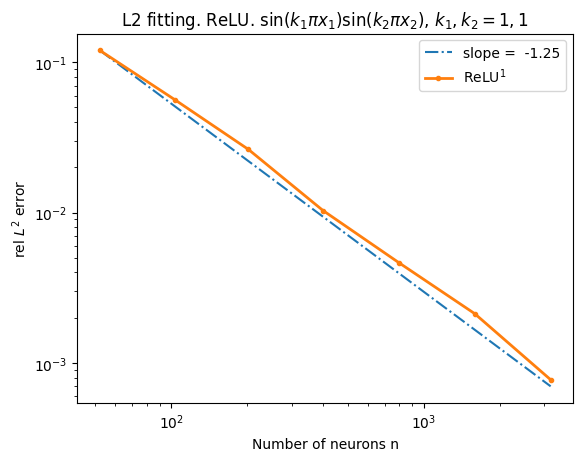

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
52.0 		 & 1.200e-01 &		 *  \\ \hline  

103.0 		 &  5.643e-02 &  		 1.10  \\ \hline  

202.0 		 &  2.630e-02 &  		 1.13  \\ \hline  

399.0 		 &  1.032e-02 &  		 1.37  \\ \hline  

800.0 		 &  4.628e-03 &  		 1.15  \\ \hline  

1592.0 		 &  2.131e-03 &  		 1.13  \\ \hline  

3186.0 		 &  7.742e-04 &  		 1.46  \\ \hline  



In [ ]:
k1 = 1
k2 = 1 

def target(x): 
    z = torch.sin(k1 * pi*x[:,0:1])*torch.sin(k2 * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 
relu_k = 1 
d = 2 
# collocation points and weights 
x = torch.linspace(-1,1,150)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,300)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(50, 3, bl = [-1,-1], ur = [1,1])

mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,13)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    print(n)
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(2, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_3(my_model) 
        my_model = remove_redundant_neuron(my_model, dims = d, choice = 2)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
        sol =torch.tensor(sol)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        with torch.no_grad(): 
            nn_func_values = my_model(x_test) 
        target_values = target(x_test) 
        target_norm = target_values.norm()
        print(target_norm)
        rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 


if relu_k == 1:
    title = "L2 fitting. ReLU. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(k1, k2)
else:
    title = "L2 fitting. ReLU$^{}$. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(relu_k, k1, k2)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)
output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)

Number of neurons removed:  12
Number of neurons left:  52
tensor(149.5000)
Number of neurons removed:  25
Number of neurons left:  103
tensor(149.5000)
Number of neurons removed:  54
Number of neurons left:  202
tensor(149.5000)
Number of neurons removed:  113
Number of neurons left:  399
tensor(149.5000)
Number of neurons removed:  224
Number of neurons left:  800
tensor(149.5000)
Number of neurons removed:  456
Number of neurons left:  1592
tensor(149.5000)
Number of neurons removed:  910
Number of neurons left:  3186
tensor(149.5000)


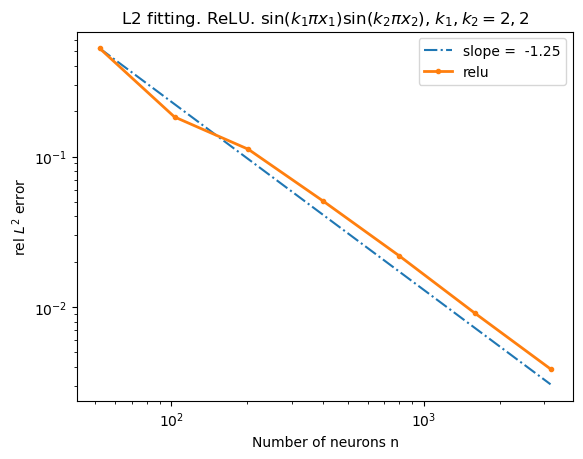

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
52.0 		 & 5.249e-01 &		 *  \\ \hline  

103.0 		 &  1.835e-01 &  		 1.54  \\ \hline  

202.0 		 &  1.119e-01 &  		 0.73  \\ \hline  

399.0 		 &  5.078e-02 &  		 1.16  \\ \hline  

800.0 		 &  2.193e-02 &  		 1.21  \\ \hline  

1592.0 		 &  9.138e-03 &  		 1.27  \\ \hline  

3186.0 		 &  3.873e-03 &  		 1.24  \\ \hline  



In [73]:
k1 = 2 
k2 = 2 

def target(x): 
    z = torch.sin(k1 * pi*x[:,0:1])*torch.sin(k2 * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 
relu_k = 1 
d = 2 
# collocation points and weights 
x = torch.linspace(-1,1,150)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,300)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(50, 3, bl = [-1,-1], ur = [1,1])

mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,13)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(2, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_3(my_model) 
        my_model = remove_redundant_neuron(my_model, dims = d, choice = 2)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
        sol =torch.tensor(sol)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        with torch.no_grad(): 
            nn_func_values = my_model(x_test) 
        target_values = target(x_test) 
        target_norm = target_values.norm()
        print(target_norm)
        rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 


if relu_k == 1:
    title = "L2 fitting. ReLU. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(k1, k2)
else:
    title = "L2 fitting. ReLU$^{}$. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(relu_k, k1, k2)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)

output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)

Number of neurons removed:  12
Number of neurons left:  52
tensor(149.5000)
Number of neurons removed:  25
Number of neurons left:  103
tensor(149.5000)
Number of neurons removed:  54
Number of neurons left:  202
tensor(149.5000)
Number of neurons removed:  113
Number of neurons left:  399
tensor(149.5000)
Number of neurons removed:  224
Number of neurons left:  800
tensor(149.5000)
Number of neurons removed:  456
Number of neurons left:  1592
tensor(149.5000)
Number of neurons removed:  910
Number of neurons left:  3186
tensor(149.5000)


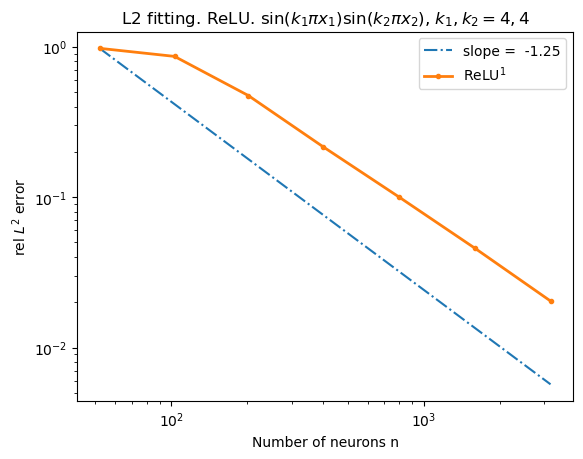

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
52.0 		 & 9.760e-01 &		 *  \\ \hline  

103.0 		 &  8.626e-01 &  		 0.18  \\ \hline  

202.0 		 &  4.737e-01 &  		 0.89  \\ \hline  

399.0 		 &  2.167e-01 &  		 1.15  \\ \hline  

800.0 		 &  1.001e-01 &  		 1.11  \\ \hline  

1592.0 		 &  4.593e-02 &  		 1.13  \\ \hline  

3186.0 		 &  2.038e-02 &  		 1.17  \\ \hline  



In [77]:
k1 = 4 
k2 = 4 

def target(x): 
    z = torch.sin(k1 * pi*x[:,0:1])*torch.sin(k2 * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 
relu_k = 1 
d = 2 
# collocation points and weights 
x = torch.linspace(-1,1,150)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,300)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(50, 3, bl = [-1,-1], ur = [1,1])

mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,13)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(2, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_3(my_model) 
        my_model = remove_redundant_neuron(my_model, dims = d, choice = 2)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
        sol =torch.tensor(sol)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        with torch.no_grad(): 
            nn_func_values = my_model(x_test) 
        target_values = target(x_test) 
        target_norm = target_values.norm()
        print(target_norm)
        rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 


if relu_k == 1:
    title = "L2 fitting. ReLU. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(k1, k2)
else:
    title = "L2 fitting. ReLU$^{}$. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(relu_k, k1, k2)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)

output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)

In [ ]:
## 

Number of neurons removed:  12
Number of neurons left:  52
tensor(149.5000)
Number of neurons removed:  25
Number of neurons left:  103
tensor(149.5000)
Number of neurons removed:  54
Number of neurons left:  202
tensor(149.5000)
Number of neurons removed:  113
Number of neurons left:  399
tensor(149.5000)
Number of neurons removed:  224
Number of neurons left:  800
tensor(149.5000)
Number of neurons removed:  456
Number of neurons left:  1592
tensor(149.5000)
Number of neurons removed:  910
Number of neurons left:  3186
tensor(149.5000)


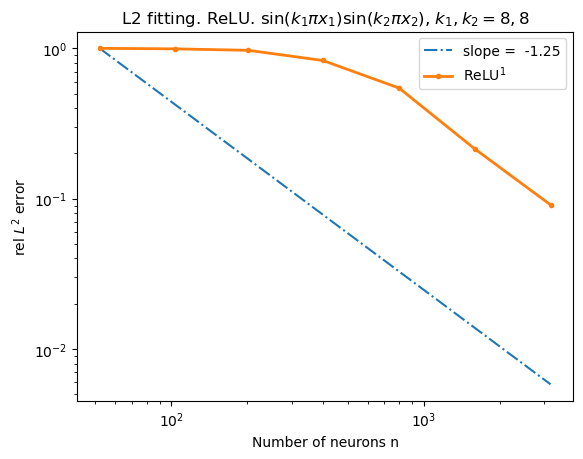

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
52.0 		 & 9.986e-01 &		 *  \\ \hline  

103.0 		 &  9.906e-01 &  		 0.01  \\ \hline  

202.0 		 &  9.684e-01 &  		 0.03  \\ \hline  

399.0 		 &  8.289e-01 &  		 0.23  \\ \hline  

800.0 		 &  5.435e-01 &  		 0.61  \\ \hline  

1592.0 		 &  2.148e-01 &  		 1.35  \\ \hline  

3186.0 		 &  9.093e-02 &  		 1.24  \\ \hline  



In [ ]:
k1 = 8 
k2 = 8 

def target(x): 
    z = torch.sin(k1 * pi*x[:,0:1])*torch.sin(k2 * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 
relu_k = 1 
d = 2 
# collocation points and weights 
x = torch.linspace(-1,1,150)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
integration_weights = 1/x_train.size(0)
integration_points = x_train 
x = torch.linspace(-1,1,300)
X1, X2 = torch.meshgrid(x,x, indexing='ij')
x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(50, 3, bl = [-1,-1], ur = [1,1])

mean_err_l2_list = [] # mean squared error 
mean_err_l2_list_2 = [] #exact L^2 error 
neuron_num_arr= np.array([2**i for i in range(6,13)]) 
actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
for i,n in enumerate(neuron_num_arr): 
    trial_num = 1
    err_l2_trial = torch.zeros(trial_num) 
    err_l2_trial_2 = torch.zeros(trial_num)
    for trial in range(trial_num):
        #1. initialize model 
        my_model = model(2, n, 1, k=relu_k).to(device) 
        #2. remove redundant neurons
        my_model = initialize_model_3(my_model) 
        my_model = remove_redundant_neuron(my_model, dims = d, choice = 2)
        actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
        D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
        D, b_rhs = rescale_mat_rhs(D,b_rhs)
        sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
        sol =torch.tensor(sol)
        my_model.fc2.weight.data[0,:] = sol.view(-1) 

        with torch.no_grad(): 
            nn_func_values = my_model(x_test) 
        target_values = target(x_test) 
        target_norm = target_values.norm()
        print(target_norm)
        rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
        err_l2_trial[trial] = rel_errl2 

        #evaluate error using exact Gauss quadrature rule
        with torch.no_grad():
            nn_func_values_2 = my_model(integration_points_test)
        target_values_2 = target(integration_points_test)
        # target_norm_2 = target_values_2.norm()
        rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
        err_l2_trial_2[trial] = rel_errl2_2**0.5 

    mean_err_l2 = torch.mean(err_l2_trial) 
    mean_err_l2_list.append(mean_err_l2) 

    mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

mean_err_l2_arr = np.array(mean_err_l2_list) 
mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 


if relu_k == 1:
    title = "L2 fitting. ReLU. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(k1, k2)
else:
    title = "L2 fitting. ReLU$^{}$. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(relu_k, k1, k2)
plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)

output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
# output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)

## relu 2


Number of neurons removed:  9
Number of neurons left:  55
tensor(149.5000)
Number of neurons removed:  22
Number of neurons left:  106
tensor(149.5000)
Number of neurons removed:  51
Number of neurons left:  205
tensor(149.5000)
Number of neurons removed:  110
Number of neurons left:  402
tensor(149.5000)
Number of neurons removed:  221
Number of neurons left:  803
tensor(149.5000)
Number of neurons removed:  453
Number of neurons left:  1595
tensor(149.5000)
Number of neurons removed:  907
Number of neurons left:  3189
tensor(149.5000)


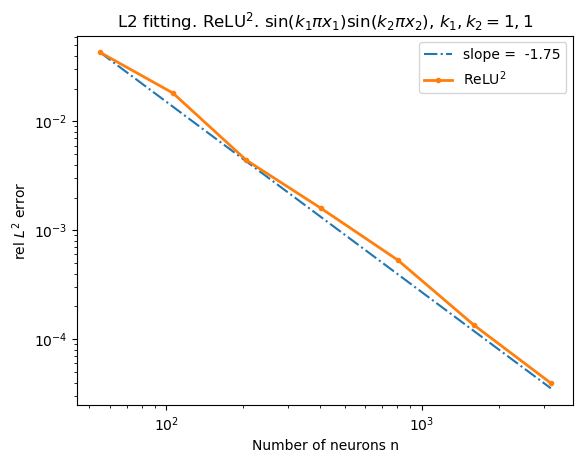

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
55.0 		 & 4.312e-02 &		 *  \\ \hline  

106.0 		 &  1.826e-02 &  		 1.31  \\ \hline  

205.0 		 &  4.427e-03 &  		 2.15  \\ \hline  

402.0 		 &  1.597e-03 &  		 1.51  \\ \hline  

803.0 		 &  5.340e-04 &  		 1.58  \\ \hline  

1595.0 		 &  1.348e-04 &  		 2.01  \\ \hline  

3189.0 		 &  3.952e-05 &  		 1.77  \\ \hline  

Number of neurons removed:  9
Number of neurons left:  55
tensor(149.5000)
Number of neurons removed:  22
Number of neurons left:  106
tensor(149.5000)
Number of neurons removed:  51
Number of neurons left:  205
tensor(149.5000)
Number of neurons removed:  110
Number of neurons left:  402
tensor(149.5000)
Number of neurons removed:  221
Number of neurons left:  803
tensor(149.5000)
Number of neurons removed:  453
Number of neurons left:  1595
tensor(149.5000)
Number of neurons removed:  907
Number of neurons left:  3189
tensor(149.5000)


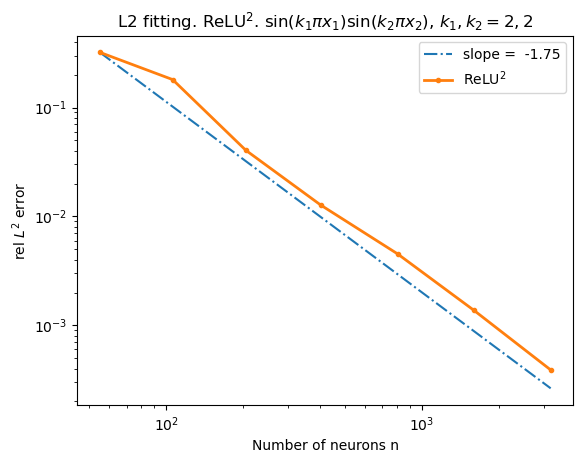

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
55.0 		 & 3.213e-01 &		 *  \\ \hline  

106.0 		 &  1.805e-01 &  		 0.88  \\ \hline  

205.0 		 &  4.045e-02 &  		 2.27  \\ \hline  

402.0 		 &  1.272e-02 &  		 1.72  \\ \hline  

803.0 		 &  4.532e-03 &  		 1.49  \\ \hline  

1595.0 		 &  1.376e-03 &  		 1.74  \\ \hline  

3189.0 		 &  3.892e-04 &  		 1.82  \\ \hline  

Number of neurons removed:  9
Number of neurons left:  55
tensor(149.5000)
Number of neurons removed:  22
Number of neurons left:  106
tensor(149.5000)
Number of neurons removed:  51
Number of neurons left:  205
tensor(149.5000)
Number of neurons removed:  110
Number of neurons left:  402
tensor(149.5000)
Number of neurons removed:  221
Number of neurons left:  803
tensor(149.5000)
Number of neurons removed:  453
Number of neurons left:  1595
tensor(149.5000)
Number of neurons removed:  907
Number of neurons left:  3189
tensor(149.5000)


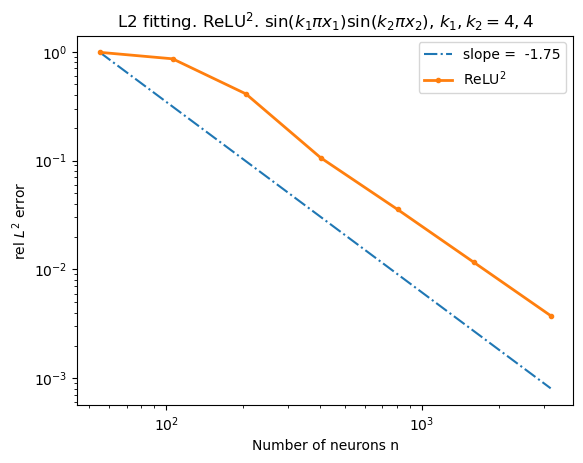

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
55.0 		 & 9.855e-01 &		 *  \\ \hline  

106.0 		 &  8.591e-01 &  		 0.21  \\ \hline  

205.0 		 &  4.093e-01 &  		 1.12  \\ \hline  

402.0 		 &  1.060e-01 &  		 2.01  \\ \hline  

803.0 		 &  3.557e-02 &  		 1.58  \\ \hline  

1595.0 		 &  1.164e-02 &  		 1.63  \\ \hline  

3189.0 		 &  3.759e-03 &  		 1.63  \\ \hline  

Number of neurons removed:  9
Number of neurons left:  55
tensor(149.5000)
Number of neurons removed:  22
Number of neurons left:  106
tensor(149.5000)
Number of neurons removed:  51
Number of neurons left:  205
tensor(149.5000)
Number of neurons removed:  110
Number of neurons left:  402
tensor(149.5000)
Number of neurons removed:  221
Number of neurons left:  803
tensor(149.5000)
Number of neurons removed:  453
Number of neurons left:  1595
tensor(149.5000)
Number of neurons removed:  907
Number of neurons left:  3189
tensor(149.5000)


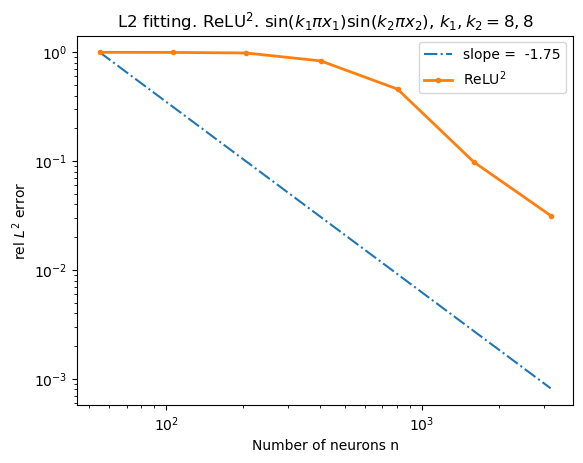

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
55.0 		 & 9.986e-01 &		 *  \\ \hline  

106.0 		 &  9.966e-01 &  		 0.00  \\ \hline  

205.0 		 &  9.848e-01 &  		 0.02  \\ \hline  

402.0 		 &  8.334e-01 &  		 0.25  \\ \hline  

803.0 		 &  4.589e-01 &  		 0.86  \\ \hline  

1595.0 		 &  9.837e-02 &  		 2.24  \\ \hline  

3189.0 		 &  3.162e-02 &  		 1.64  \\ \hline  



In [78]:

for ks in [[1,1],[2,2],[4,4],[8,8]]: 
    k1 = ks[0]
    k2 = ks[1]
    def target(x): 
        z = torch.sin(k1 * pi*x[:,0:1])*torch.sin(k2 * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
        return z 
    relu_k = 2 
    d = 2 
    # collocation points and weights 
    x = torch.linspace(-1,1,150)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_train = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)
    integration_weights = 1/x_train.size(0)
    integration_points = x_train 
    x = torch.linspace(-1,1,300)
    X1, X2 = torch.meshgrid(x,x, indexing='ij')
    x_test = torch.concat([X1.reshape(-1,1), X2.reshape(-1,1)], dim=1)

    integration_weights_test, integration_points_test = PiecewiseGQ2D_weights_points(50, 3, bl = [-1,-1], ur = [1,1])

    mean_err_l2_list = [] # mean squared error 
    mean_err_l2_list_2 = [] #exact L^2 error 
    neuron_num_arr= np.array([2**i for i in range(6,13)]) 
    actual_neuron_arr = np.zeros(len(neuron_num_arr)) 
    for i,n in enumerate(neuron_num_arr): 
        trial_num = 1
        err_l2_trial = torch.zeros(trial_num) 
        err_l2_trial_2 = torch.zeros(trial_num)
        for trial in range(trial_num):
            #1. initialize model 
            my_model = model(2, n, 1, k=relu_k).to(device) 
            #2. remove redundant neurons
            my_model = initialize_model_3(my_model) 
            my_model = remove_redundant_neuron(my_model, dims = d, choice = 2)
            actual_neuron_arr[i] = my_model.fc1.bias.size(0) 
            D,b_rhs = assemble_least_square_linear_system_quadrature(my_model,target,integration_weights, integration_points)
            D, b_rhs = rescale_mat_rhs(D,b_rhs)
            sol = scipy.linalg.lstsq(D.numpy(),b_rhs.numpy())[0]
            sol =torch.tensor(sol)
            my_model.fc2.weight.data[0,:] = sol.view(-1) 

            with torch.no_grad(): 
                nn_func_values = my_model(x_test) 
            target_values = target(x_test) 
            target_norm = target_values.norm()
            print(target_norm)
            rel_errl2 = (nn_func_values - target_values).norm()/target_norm.norm()
            err_l2_trial[trial] = rel_errl2 

            #evaluate error using exact Gauss quadrature rule
            with torch.no_grad():
                nn_func_values_2 = my_model(integration_points_test)
            target_values_2 = target(integration_points_test)
            # target_norm_2 = target_values_2.norm()
            rel_errl2_2 = integration_weights_test.t() @ (nn_func_values_2 - target_values_2)**2
            err_l2_trial_2[trial] = rel_errl2_2**0.5 

        mean_err_l2 = torch.mean(err_l2_trial) 
        mean_err_l2_list.append(mean_err_l2) 

        mean_err_l2_list_2.append(torch.mean(err_l2_trial_2))

    mean_err_l2_arr = np.array(mean_err_l2_list) 
    mean_err_l2_arr_2 = np.array(mean_err_l2_list_2) 


    if relu_k == 1:
        title = "L2 fitting. ReLU. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(k1, k2)
    else:
        title = "L2 fitting. ReLU$^{}$. $\sin(k_1\pi x_1) \sin(k_2\pi x_2)$, $k_1,k_2 = {}, {}$".format(relu_k, k1, k2)
    plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title)

    output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr)
    # output_convergence_order_l2(actual_neuron_arr,mean_err_l2_arr_2)